# Financial Returns Prediction with LSTM (MLX)

This notebook mirrors the XGBoost workflow (`513_financial_xgboost.ipynb`) but trains sequence models using **MLX** (Apple Silicon). It keeps the same data prep and feature definitions so you can compare models side-by-side.

> Requires the MLX package (Apple Silicon). Install if needed: `pip install mlx` (and optionally `pip install mlx-lm`).

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import mlx.core as mx
import mlx.nn as nn
from mlx.optimizers import AdamW

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Display and plotting options
pd.options.display.float_format = "{:.4f}".format
plt.rcParams["figure.figsize"] = (12, 4)

DATA_DIR = "./data/"
OUTPUT_DIR = "./data/"

RAW_FINANCIAL_FILE = DATA_DIR + "market_data.json"
EPI_FILE = DATA_DIR + "epi_data.json"

# Analysis window (same as XGBoost notebook)
START_DATE = "2025-01-01"
END_DATE = "2025-05-31"

np.random.seed(42)
mx.random.seed(42)


## 1. Load and Prepare Data

In [2]:

# --- Load raw financial data ---
try:
    df_raw = pd.read_json(RAW_FINANCIAL_FILE)
except ValueError:
    df_raw = pd.read_csv(RAW_FINANCIAL_FILE)

if "Date_" not in df_raw.columns:
    raise KeyError("Expected a 'Date_' column in the market data file.")

# Parse dates and sort
df_raw["Date_"] = pd.to_datetime(df_raw["Date_"])
df_raw = df_raw.sort_values("Date_").set_index("Date_")

# Rename columns to simpler names (matches XGBoost notebook)
rename_map = {
    "Close_BTC-USD": "close_btc",
    "Close_GC=F": "close_gold",
    "Close_CL=F": "close_oil",
    "Close_^GSPC": "close_spx",
    "Close_CNY=X": "close_usdcny",
    "Close_EUR=X": "close_eurusd",
    "Close_^TNX": "close_ust10y",
    "Volume_BTC-USD": "vol_btc",
    "Volume_GC=F": "vol_gold",
    "Volume_^GSPC": "vol_spx",
}

df = df_raw.rename(columns=rename_map)

# Create business-day index and forward-fill prices
full_index = pd.date_range(df.index.min(), df.index.max(), freq="B")
df = df.reindex(full_index)
price_cols = [c for c in df.columns if c.startswith("close_")]
df[price_cols] = df[price_cols].ffill()

# Construct returns and control variables
def log_return(series):
    return np.log(series).diff()

returns = pd.DataFrame(index=df.index)
returns["r_btc"] = log_return(df["close_btc"])
returns["r_gold"] = log_return(df["close_gold"])
returns["r_spx"] = log_return(df["close_spx"])

returns["dln_eurusd"] = log_return(df["close_eurusd"])
returns["dln_usdcny"] = log_return(df["close_usdcny"])
returns["dln_oil"] = log_return(df["close_oil"])
returns["dy10"] = df["close_ust10y"].diff()

returns = returns.dropna().loc[START_DATE:END_DATE]

# Load EPI data
df_epi = pd.read_json(EPI_FILE)
df_epi['date'] = pd.to_datetime(df_epi['date'])
df_epi = df_epi.set_index('date')

epi_cols = [col for col in df_epi.columns if col.startswith('epi') or col in ['ei_creator', 'ei_community']]

returns = returns.join(df_epi[epi_cols], how='left')
returns[epi_cols] = returns[epi_cols].fillna(0)

print(f"Data window: {returns.index.min().date()} to {returns.index.max().date()}")
print(f"Columns: {returns.columns.tolist()}")


Data window: 2025-01-01 to 2025-05-30
Columns: ['r_btc', 'r_gold', 'r_spx', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'ei_creator', 'ei_community', 'epi', 'epi_weighted', 'epi_', 'epi_Environmental and Infrastructure', 'epi_Labor and Workforce', 'epi_Health and Social Welfare', 'epi_Legal and Regulatory Framework', 'epi_Education and Knowledge', 'epi_Psychological and Emotional Aspects', 'epi_Leadership and Governance', 'epi_Economic and Financial Matters', 'epi_Disaster and Resilience', 'epi_Security and Conflict', 'epi_Disputes and Opinions', 'epi_Miscellaneous and Other', 'epi_Sports and Recreation', 'epi_Power and Influence Dynamics', 'epi_Social and Cultural Aspects', 'epi_Quality of Life and Standards', 'epi_Trust, Credibility, and Communication', 'epi_Conspiracy and Historical Events']


## 2. Feature Engineering (lags, asymmetry, rolling stats)

In [3]:

max_lag = 5
data = returns.copy()

for asset in ["r_btc", "r_gold", "r_spx"]:
    for lag in range(1, max_lag + 1):
        data[f"{asset}_l{lag}"] = data[asset].shift(lag)

for lag in range(1, max_lag + 1):
    data[f'epi_l{lag}'] = data['epi'].shift(lag)
    data[f'epi_weighted_l{lag}'] = data['epi_weighted'].shift(lag)

# Asymmetric and rolling stats
data['epi_pos'] = np.maximum(data['epi'], 0)
data['epi_neg'] = np.minimum(data['epi'], 0)
data['epi_weighted_pos'] = np.maximum(data['epi_weighted'], 0)
data['epi_weighted_neg'] = np.minimum(data['epi_weighted'], 0)

data['epi_ma5'] = data['epi'].rolling(5).mean()
data['epi_std5'] = data['epi'].rolling(5).std()
data['epi_weighted_ma5'] = data['epi_weighted'].rolling(5).mean()
data['epi_weighted_std5'] = data['epi_weighted'].rolling(5).std()

for asset in ["r_btc", "r_gold", "r_spx"]:
    data[f"{asset}_vol5"] = data[asset].rolling(5).std()

data = data.dropna()
print(f"Feature-engineered data shape: {data.shape}")


Feature-engineered data shape: (103, 66)


## 3. Feature Sets (same definitions as XGBoost notebook)

In [4]:

control_cols = ["dln_eurusd", "dln_usdcny", "dln_oil", "dy10"]


def get_feature_cols(asset, model_type="baseline"):
    """
    Return feature columns for each model type.
    - baseline: lagged returns + controls + vol
    - epi / epi_weighted: add contemporaneous EPI variant
    - epi_lagged: add EPI lags
    - epi_full: asymmetric + lags + rolling stats
    - epi_weighted_full: weighted version of epi_full
    """
    lag_cols = [f"{asset}_l{lag}" for lag in range(1, 4)]
    other_assets = [a for a in ["r_btc", "r_gold", "r_spx"] if a != asset]
    cross_cols = [f"{a}_l1" for a in other_assets]
    vol_cols = [f"{asset}_vol5"]
    base_features = lag_cols + cross_cols + control_cols + vol_cols

    if model_type == "baseline":
        return base_features
    if model_type == "epi":
        return base_features + ["epi"]
    if model_type == "epi_weighted":
        return base_features + ["epi_weighted"]
    if model_type == "epi_lagged":
        epi_lags = [f"epi_l{lag}" for lag in range(1, 4)]
        return base_features + epi_lags
    if model_type == "epi_asymmetric":
        return base_features + ["epi_pos", "epi_neg"]
    if model_type == "epi_full":
        epi_lags = [f"epi_l{lag}" for lag in range(1, 4)]
        epi_roll = ["epi_ma5", "epi_std5"]
        return base_features + ["epi", "epi_pos", "epi_neg"] + epi_lags + epi_roll
    if model_type == "epi_weighted_full":
        epi_lags = [f"epi_weighted_l{lag}" for lag in range(1, 4)]
        epi_roll = ["epi_weighted_ma5", "epi_weighted_std5"]
        return base_features + ["epi_weighted", "epi_weighted_pos", "epi_weighted_neg"] + epi_lags + epi_roll
    raise ValueError(f"Unknown model type: {model_type}")

print(get_feature_cols("r_btc", "epi_full"))


['r_btc_l1', 'r_btc_l2', 'r_btc_l3', 'r_gold_l1', 'r_spx_l1', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'r_btc_vol5', 'epi', 'epi_pos', 'epi_neg', 'epi_l1', 'epi_l2', 'epi_l3', 'epi_ma5', 'epi_std5']


## 4. MLX LSTM helpers (sequence builder, model, training loop)

In [17]:
from typing import Dict, List, Tuple, Optional
import copy
import mlx.utils


def make_sequences(features: np.ndarray, targets: np.ndarray, seq_len: int, index: pd.Index):
    X_seq, y_seq, seq_dates = [], [], []
    for i in range(seq_len, len(features)):
        X_seq.append(features[i - seq_len : i])
        y_seq.append(targets[i])
        seq_dates.append(index[i])
    return (
        np.array(X_seq, dtype=np.float32),
        np.array(y_seq, dtype=np.float32),
        pd.Index(seq_dates),
    )


def compute_metrics(actuals: np.ndarray, preds: np.ndarray) -> Dict[str, float]:
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    # Handle zero returns for directional accuracy
    mask = actuals != 0
    if mask.sum() > 0:
        dir_acc = np.mean(np.sign(actuals[mask]) == np.sign(preds[mask])) * 100
    else:
        dir_acc = 50.0
    return {"rmse": rmse, "mae": mae, "dir_acc": dir_acc}


def copy_weights(weights):
    """Deep copy model weights (nested dict of arrays)."""
    return mlx.utils.tree_map(lambda x: mx.array(x), weights)


class TemporalAttention(nn.Module):
    """Simple attention over timesteps to focus on important periods."""
    
    def __init__(self, hidden_size: int):
        super().__init__()
        self.attention = nn.Linear(hidden_size, 1)
    
    def __call__(self, x):
        # x: (batch, seq_len, hidden)
        scores = self.attention(x)  # (batch, seq_len, 1)
        weights = mx.softmax(scores, axis=1)
        # Weighted sum over timesteps
        context = mx.sum(x * weights, axis=1)  # (batch, hidden)
        return context, weights


class ImprovedLSTMRegressor(nn.Module):
    """Enhanced LSTM with attention, layer norm, and residual connections."""

    def __init__(
        self, 
        input_size: int, 
        hidden_size: int = 64, 
        num_layers: int = 2, 
        dropout: float = 0.2,
        use_attention: bool = True,
        use_layer_norm: bool = True,
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout_rate = dropout
        self.use_attention = use_attention
        self.use_layer_norm = use_layer_norm
        
        # Input projection for residual
        self.input_proj = nn.Linear(input_size, hidden_size) if input_size != hidden_size else None
        
        # Stack LSTM layers
        self.lstm_layers = []
        self.layer_norms = [] if use_layer_norm else None
        
        for i in range(num_layers):
            layer_input_size = input_size if i == 0 else hidden_size
            self.lstm_layers.append(nn.LSTM(layer_input_size, hidden_size))
            if use_layer_norm:
                self.layer_norms.append(nn.LayerNorm(hidden_size))
        
        # Dropout
        self.dropout = nn.Dropout(p=dropout) if dropout > 0 else None
        
        # Attention mechanism
        self.attention = TemporalAttention(hidden_size) if use_attention else None
        
        # Output head with extra hidden layer
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc2 = nn.Linear(hidden_size // 2, 1)

    def __call__(self, x):
        # x: (batch, seq_len, features)
        batch_size, seq_len, _ = x.shape
        
        # MLX LSTM expects (seq_len, batch, features)
        out = mx.swapaxes(x, 0, 1)
        
        for i, lstm in enumerate(self.lstm_layers):
            lstm_out, _ = lstm(out)
            
            # Layer normalization
            if self.use_layer_norm:
                # Swap to (batch, seq, hidden) for layer norm
                lstm_out_t = mx.swapaxes(lstm_out, 0, 1)
                lstm_out_t = self.layer_norms[i](lstm_out_t)
                lstm_out = mx.swapaxes(lstm_out_t, 0, 1)
            
            # Residual connection (after first layer)
            if i > 0:
                lstm_out = lstm_out + out
            
            # Dropout between layers
            if self.dropout is not None and i < self.num_layers - 1:
                lstm_out = self.dropout(lstm_out)
            
            out = lstm_out
        
        # Swap back: (seq, batch, hidden) -> (batch, seq, hidden)
        out = mx.swapaxes(out, 0, 1)
        
        # Attention or last timestep
        if self.use_attention:
            context, _ = self.attention(out)
        else:
            context = out[:, -1, :]
        
        # Two-layer head with GELU activation
        h = nn.gelu(self.fc1(context))
        if self.dropout is not None:
            h = self.dropout(h)
        return self.fc2(h).squeeze(-1)


def get_lr_schedule(epoch: int, total_epochs: int, base_lr: float, warmup_epochs: int = 5) -> float:
    """Cosine annealing with linear warmup."""
    if epoch < warmup_epochs:
        return base_lr * (epoch + 1) / warmup_epochs
    else:
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return base_lr * 0.5 * (1 + np.cos(np.pi * progress))


def clip_gradients(grads, max_norm: float = 1.0):
    """Clip gradients by global norm."""
    def compute_norm(g):
        if isinstance(g, mx.array):
            return float(mx.sum(g * g))
        return 0.0
    
    total_norm_sq = mlx.utils.tree_reduce(lambda acc, g: acc + compute_norm(g), grads, 0.0)
    total_norm = np.sqrt(total_norm_sq)
    
    if total_norm > max_norm:
        scale = max_norm / (total_norm + 1e-6)
        grads = mlx.utils.tree_map(lambda g: g * scale if isinstance(g, mx.array) else g, grads)
    
    return grads


def train_lstm_model(
    df: pd.DataFrame,
    asset: str,
    feature_cols: List[str],
    seq_len: int = 15,  # Reduced for small dataset
    hidden_size: int = 32,  # Smaller to reduce overfitting
    num_layers: int = 2,
    dropout: float = 0.2,
    learning_rate: float = 1e-3,
    epochs: int = 100,
    batch_size: int = 16,  # Smaller batches
    patience: int = 15,  # More patience
    train_ratio: float = 0.7,
    val_ratio: float = 0.15,
    use_attention: bool = True,
    use_layer_norm: bool = True,
    grad_clip: float = 1.0,
    verbose: bool = True,
):
    df_fit = df.dropna(subset=[asset] + feature_cols)
    if len(df_fit) <= seq_len + 10:
        return {"error": "Insufficient data after lagging for LSTM."}

    # Time-based split
    train_end = int(len(df_fit) * train_ratio)
    val_end = int(len(df_fit) * (train_ratio + val_ratio))

    features = df_fit[feature_cols].values.astype(np.float32)
    target = df_fit[asset].values.astype(np.float32)

    # Robust scaling (less sensitive to outliers)
    scaler = StandardScaler()
    scaler.fit(features[:train_end])
    features_scaled = scaler.transform(features)

    X_seq, y_seq, seq_dates = make_sequences(features_scaled, target, seq_len, df_fit.index)

    train_cut = max(train_end - seq_len, 1)
    val_cut = max(val_end - seq_len, train_cut + 1)

    X_train, y_train = X_seq[:train_cut], y_seq[:train_cut]
    X_val, y_val = X_seq[train_cut:val_cut], y_seq[train_cut:val_cut]
    X_test, y_test = X_seq[val_cut:], y_seq[val_cut:]
    date_test = seq_dates[val_cut:]

    if len(X_test) == 0:
        return {"error": "Test window empty; reduce seq_len or adjust split."}

    # Data augmentation: add small noise to training data
    X_train_aug = X_train + np.random.normal(0, 0.01, X_train.shape).astype(np.float32)
    X_train_combined = np.concatenate([X_train, X_train_aug], axis=0)
    y_train_combined = np.concatenate([y_train, y_train], axis=0)

    model = ImprovedLSTMRegressor(
        X_train.shape[-1], 
        hidden_size=hidden_size, 
        num_layers=num_layers, 
        dropout=dropout,
        use_attention=use_attention,
        use_layer_norm=use_layer_norm,
    )
    
    # Use AdamW with weight decay
    optimizer = AdamW(learning_rate=learning_rate, weight_decay=1e-3)

    def loss_fn(model, xb, yb):
        preds = model(xb)
        mse = mx.mean((preds - yb) ** 2)
        return mse

    loss_and_grad = nn.value_and_grad(model, loss_fn)

    best_weights = None
    best_val = np.inf
    wait = 0
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # Update learning rate
        current_lr = get_lr_schedule(epoch, epochs, learning_rate)
        optimizer.learning_rate = current_lr
        
        # Training with shuffled augmented data
        perm = np.random.permutation(len(X_train_combined))
        epoch_loss = 0.0
        n_batches = 0
        
        for start in range(0, len(perm), batch_size):
            idx = perm[start : start + batch_size]
            xb = mx.array(X_train_combined[idx])
            yb = mx.array(y_train_combined[idx])
            
            loss, grads = loss_and_grad(model, xb, yb)
            
            # Gradient clipping
            if grad_clip > 0:
                grads = clip_gradients(grads, grad_clip)
            
            optimizer.update(model, grads)
            mx.eval(model.parameters(), optimizer.state)
            
            epoch_loss += float(loss)
            n_batches += 1

        avg_train_loss = epoch_loss / n_batches
        train_losses.append(avg_train_loss)

        # Validation
        if len(X_val) > 0:
            val_pred = model(mx.array(X_val))
            val_loss = float(mx.mean((val_pred - mx.array(y_val)) ** 2))
        else:
            val_loss = avg_train_loss
        val_losses.append(val_loss)

        if verbose and (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:03d} | LR {current_lr:.6f} | Train {avg_train_loss:.6f} | Val {val_loss:.6f}")

        # Early stopping with patience
        if val_loss < best_val - 1e-7:
            best_val = val_loss
            best_weights = copy_weights(model.parameters())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1}")
                break

    if best_weights is not None:
        model.update(best_weights)

    # Evaluation
    test_pred = model(mx.array(X_test))
    test_pred_np = np.asarray(test_pred).reshape(-1)
    metrics = compute_metrics(y_test, test_pred_np)

    preds_series = pd.Series(test_pred_np, index=date_test)
    actual_series = pd.Series(y_test, index=date_test)

    return {
        **metrics,
        "predictions": preds_series,
        "actuals": actual_series,
        "val_loss": best_val,
        "feature_cols": feature_cols,
        "seq_len": seq_len,
        "scaler": scaler,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "n_train": len(X_train),
        "n_val": len(X_val),
        "n_test": len(X_test),
    }

## 5. Train LSTM models across feature sets

In [18]:
assets = ["r_btc", "r_gold", "r_spx"]
# Focus on models that work well - skip epi_full which overfits
model_types = ["baseline", "epi", "epi_weighted"]

# Improved training config - smaller model, more regularization
train_cfg = {
    "seq_len": 10,           # Shorter sequences for small dataset
    "hidden_size": 32,       # Smaller to prevent overfitting
    "num_layers": 2,
    "dropout": 0.3,          # Higher dropout
    "learning_rate": 5e-4,   # Lower LR
    "epochs": 150,           # More epochs (early stopping will kick in)
    "batch_size": 8,         # Smaller batches for more updates
    "patience": 20,          # More patience
    "use_attention": True,
    "use_layer_norm": True,
    "grad_clip": 1.0,
    "verbose": False,        # Less output
}

results = {mt: {} for mt in model_types}

for model_type in model_types:
    print("=" * 70)
    print(f"Training model type: {model_type}")
    for asset in assets:
        feature_cols = get_feature_cols(asset, model_type)
        res = train_lstm_model(data, asset, feature_cols, **train_cfg)
        results[model_type][asset] = res
        if "error" in res:
            print(f"  {asset}: {res['error']}")
        else:
            print(f"  {asset}: RMSE={res['rmse']:.5f}, MAE={res['mae']:.5f}, " 
                  f"DirAcc={res['dir_acc']:.1f}%, n_test={res['n_test']}")

Training model type: baseline
  r_btc: RMSE=0.04481, MAE=0.03727, DirAcc=62.5%, n_test=16
  r_btc: RMSE=0.04481, MAE=0.03727, DirAcc=62.5%, n_test=16
  r_gold: RMSE=0.03502, MAE=0.03150, DirAcc=20.0%, n_test=16
  r_gold: RMSE=0.03502, MAE=0.03150, DirAcc=20.0%, n_test=16
  r_spx: RMSE=0.03187, MAE=0.02757, DirAcc=60.0%, n_test=16
Training model type: epi
  r_spx: RMSE=0.03187, MAE=0.02757, DirAcc=60.0%, n_test=16
Training model type: epi
  r_btc: RMSE=0.04131, MAE=0.03352, DirAcc=43.8%, n_test=16
  r_btc: RMSE=0.04131, MAE=0.03352, DirAcc=43.8%, n_test=16
  r_gold: RMSE=0.09712, MAE=0.08509, DirAcc=40.0%, n_test=16
  r_gold: RMSE=0.09712, MAE=0.08509, DirAcc=40.0%, n_test=16
  r_spx: RMSE=0.02773, MAE=0.02327, DirAcc=46.7%, n_test=16
Training model type: epi_weighted
  r_spx: RMSE=0.02773, MAE=0.02327, DirAcc=46.7%, n_test=16
Training model type: epi_weighted
  r_btc: RMSE=0.03772, MAE=0.02913, DirAcc=43.8%, n_test=16
  r_btc: RMSE=0.03772, MAE=0.02913, DirAcc=43.8%, n_test=16
  r_gold

## 6. Model comparison

In [19]:

comparison_rows = []
for model_type, asset_dict in results.items():
    for asset, res in asset_dict.items():
        if "error" in res:
            continue
        comparison_rows.append({
            "Model": model_type,
            "Asset": asset,
            "RMSE": res["rmse"],
            "MAE": res["mae"],
            "Dir Acc (%)": res["dir_acc"],
        })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values(["Asset", "RMSE"])
comparison_df


,Model,Asset,RMSE,MAE,Dir Acc (%)
6,epi_weighted,r_btc,0.0377,0.0291,43.7500
3,epi,r_btc,0.0413,0.0335,43.7500
0,baseline,r_btc,0.0448,0.0373,62.5000
7,epi_weighted,r_gold,0.0180,0.0145,80.0000
1,baseline,r_gold,0.0350,0.0315,20.0000
4,epi,r_gold,0.0971,0.0851,40.0000
8,epi_weighted,r_spx,0.0192,0.0162,53.3333
5,epi,r_spx,0.0277,0.0233,46.6667
2,baseline,r_spx,0.0319,0.0276,60.0000


In [20]:

# Improvement vs baseline
improvement_rows = []
for asset in assets:
    base = results["baseline"].get(asset)
    if not base or "error" in base:
        continue
    base_rmse = base["rmse"]
    for model_type in model_types:
        res = results[model_type].get(asset)
        if not res or "error" in res:
            continue
        rmse_imp = (base_rmse - res["rmse"]) / base_rmse * 100
        improvement_rows.append({
            "Asset": asset,
            "Model": model_type,
            "RMSE Improvement (%)": rmse_imp,
            "Dir Acc (%)": res["dir_acc"],
        })

improvement_df = pd.DataFrame(improvement_rows)
improvement_df.sort_values(["Asset", "RMSE Improvement (%)"], ascending=[True, False])


,Asset,Model,RMSE Improvement (%),Dir Acc (%)
2,r_btc,epi_weighted,15.8212,43.7500
1,r_btc,epi,7.8105,43.7500
0,r_btc,baseline,0.0000,62.5000
5,r_gold,epi_weighted,48.7421,80.0000
3,r_gold,baseline,0.0000,20.0000
4,r_gold,epi,-177.3133,40.0000
8,r_spx,epi_weighted,39.6999,53.3333
7,r_spx,epi,12.9868,46.6667
6,r_spx,baseline,0.0000,60.0000


## 7. Visualize predictions and cumulative returns (best model type)

Using best average RMSE model type: epi_weighted


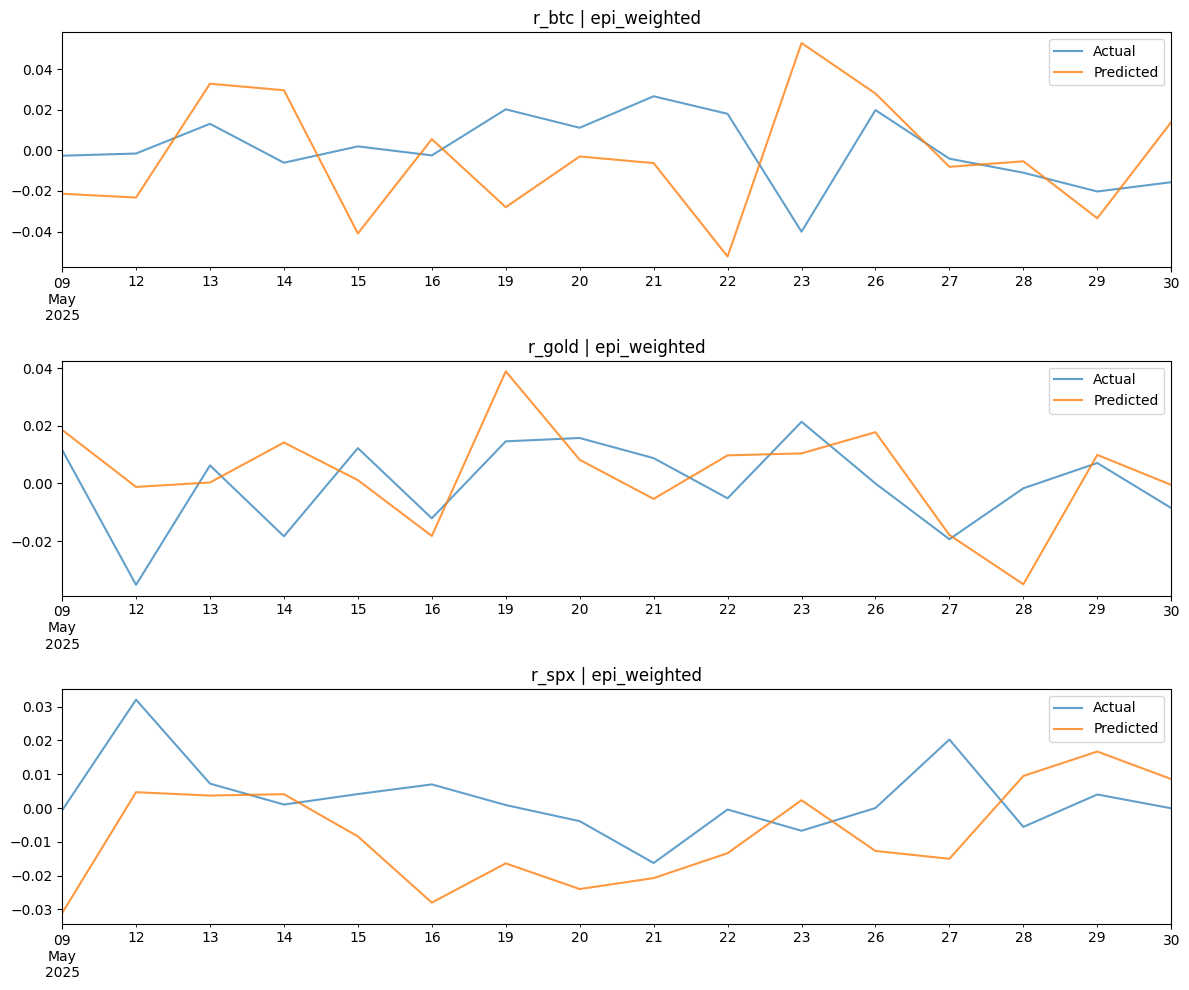

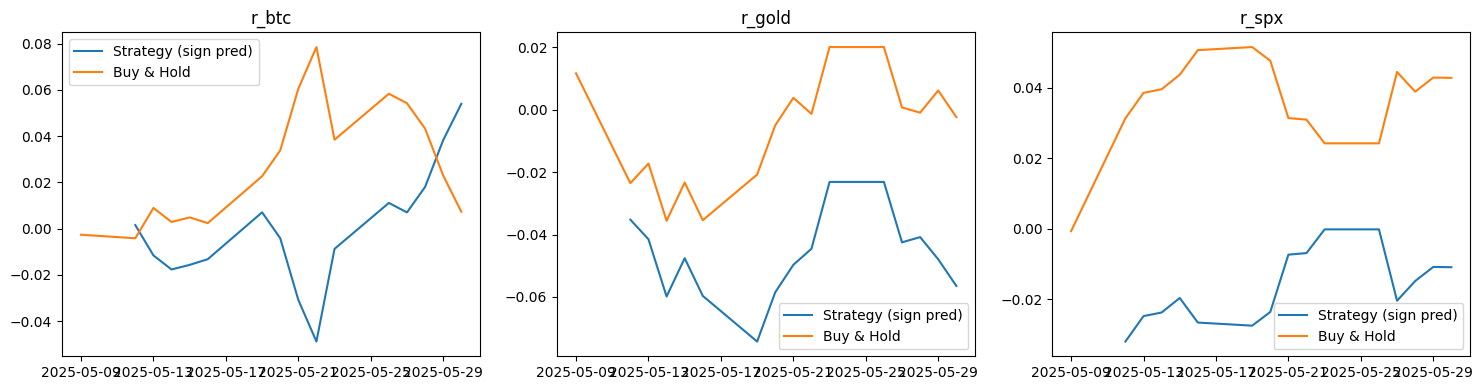

In [21]:

if not comparison_df.empty:
    best_model_type = comparison_df.groupby("Model")["RMSE"].mean().idxmin()
    print(f"Using best average RMSE model type: {best_model_type}")
else:
    best_model_type = "baseline"
    print("No successful runs; using baseline placeholder.")

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
for idx, asset in enumerate(assets):
    res = results.get(best_model_type, {}).get(asset)
    if not res or "error" in res:
        axes[idx].set_title(f"{asset}: no predictions")
        continue
    ax = axes[idx]
    res["actuals"].plot(ax=ax, label="Actual", alpha=0.7)
    res["predictions"].plot(ax=ax, label="Predicted", alpha=0.8)
    ax.set_title(f"{asset} | {best_model_type}")
    ax.legend()
plt.tight_layout()
plt.show()

# Cumulative returns using one-step-ahead sign of predictions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, asset in enumerate(assets):
    res = results.get(best_model_type, {}).get(asset)
    if not res or "error" in res:
        axes[idx].set_title(f"{asset}: no returns plot")
        continue
    actuals = res["actuals"]
    preds = res["predictions"]
    strategy = (np.sign(preds.shift(1)) * actuals).cumsum()
    buy_hold = actuals.cumsum()
    axes[idx].plot(strategy, label="Strategy (sign pred)")
    axes[idx].plot(buy_hold, label="Buy & Hold")
    axes[idx].set_title(asset)
    axes[idx].legend()
plt.tight_layout()
plt.show()


## 8. Notes / next steps
- MLX runs best on Apple Silicon with recent Python builds; if `batch_first` is unsupported, the fallback in `LSTMRegressor` handles the axis swap.
- Increase `seq_len`, `hidden_size`, and `epochs` for richer dynamics (data volume is small, so watch for overfitting).
- You can extend `model_types` to mirror every XGBoost spec or simplify to the one that works best in this window.